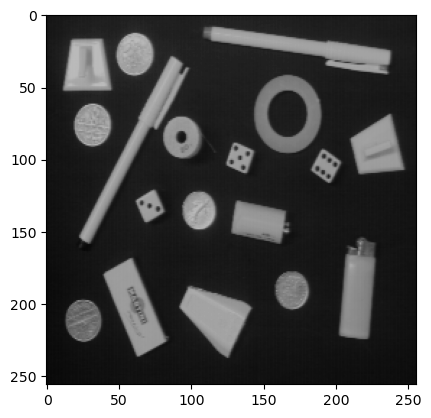

In [6]:
import cv2
import matplotlib.pyplot as plt

objects = cv2.imread('OBJECTS.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(objects, cmap='gray', vmin=0, vmax=255)
plt.show()

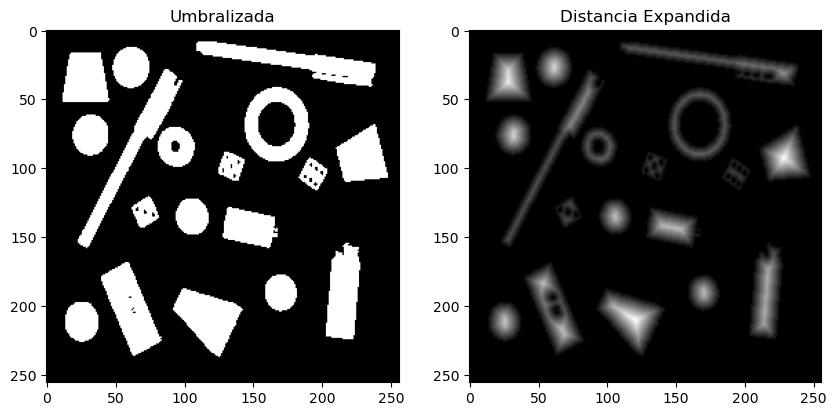

In [7]:
from skimage import exposure
from scipy.ndimage import distance_transform_edt

umbral = 70
_, objectsU = cv2.threshold(objects, umbral, 255, cv2.THRESH_BINARY)
objectsD = distance_transform_edt(objectsU)
objectsDC = exposure.rescale_intensity(objectsD, in_range=(0, objectsD.max()), out_range=(0, 255) )

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(objectsU, cmap='gray', vmin=0, vmax=255)
plt.title("Umbralizada")
plt.subplot(1, 2, 2)
plt.imshow(objectsDC, cmap='gray', vmin=0, vmax=255)
plt.title("Distancia Expandida")
plt.show()

Distancia mínima entre los lápices: 133.99 píxeles
Valor del pixel en el punto medio en el mapa de distancias: 23.77


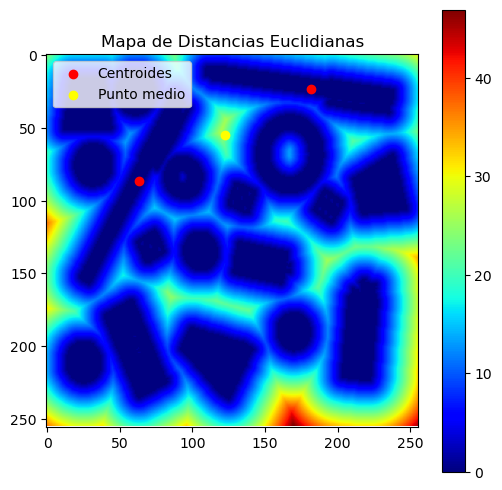

In [8]:
import numpy as np
from skimage.measure import label, regionprops
from scipy.ndimage import distance_transform_edt

objectsUN = np.logical_not(objectsU)
distancia = distance_transform_edt(objectsUN)
etiquetas = label(objectsU)
propiedades = regionprops(etiquetas)

if len(propiedades) >= 2:
    props_sorted = sorted(propiedades, key=lambda x: x.area, reverse=True)[:2]
    c1 = props_sorted[0].centroid
    c2 = props_sorted[1].centroid
    distancia_min = np.linalg.norm(np.array(c1) - np.array(c2))
    punto_medio = ((c1[0] + c2[0]) / 2, (c1[1] + c2[1]) / 2)
    valor_punto_medio = distancia[int(punto_medio[0]), int(punto_medio[1])]
    print(f"Distancia mínima entre los lápices: {distancia_min:.2f} píxeles")
    print(f"Valor del pixel en el punto medio en el mapa de distancias: {valor_punto_medio:.2f}")

plt.figure(figsize=(6, 6))
plt.imshow(distancia, cmap="jet")
plt.colorbar()
plt.scatter([c1[1], c2[1]], [c1[0], c2[0]], color='red', label="Centroides")
plt.scatter(punto_medio[1], punto_medio[0], color='yellow', label="Punto medio")
plt.legend()
plt.title("Mapa de Distancias Euclidianas")
plt.show()
